# **Model Overview: Discrete Choice Model for Affordable Housing Applications**

This notebook implements a **Bayesian discrete choice model** designed to understand how applicants from different demographic groups make decisions about applying to affordable housing opportunities. The model was developed as part of a collaboration with **CHAPA**, with the goal of providing a transparent, data-driven way to study equity and access in lottery application patterns.

Rather than simply predicting who applies, the model aims to **quantify how different applicant characteristics and property attributes influence the probability of applying**, and how these relationships differ across racial and ethnic groups.

---

## **What the Model Does**

At a high level, the model represents each applicant’s decision to apply (or not apply) as a function of:

* **Applicant characteristics**

  * Age
  * Disability status
  * Number of dependents
  * Household income

* **Property characteristics**

  * Maximum resale price
  * Distance from the applicant’s home to the property

* **Demographic group**

  * The model allows each racial or ethnic group to have its own set of coefficients, capturing potential differences in how various factors shape application decisions.

These inputs are combined to form a **utility score**, which is then passed through a logistic (sigmoid) function to obtain the **probability of application** for each applicant–property pair.

The model is fully probabilistic: it does not output single estimates, but **posterior distributions**, giving us uncertainty intervals around all effects.

---

## **Why This Model Works**

Discrete choice models are widely used in economics and policy analysis because they mirror the way real decisions are made. The intuition is simple:

1. Each applicant receives a “utility” from each property, based on its features and their own characteristics.
2. Utility is modeled as a linear combination of effects (e.g., how income interacts with resale price).
3. Random variation is captured through applicant-level uncertainty.
4. The higher the utility, the more likely the applicant is to apply.

This Bayesian formulation offers several advantages:

* **Hierarchical race-specific effects**:
  In *Model 2*, Each racial/ethnic group gets its own set of coefficients, allowing us to examine heterogeneity without overfitting.

* **Partial pooling**:
  The model shrinks extreme subgroup estimates toward the overall mean, improving robustness when some groups have fewer observations.

* **Uncertainty quantification**:
  Instead of a single point estimate, the model provides a distribution for each effect.

* **Applicant-level variability**:
  A random effect (if computationally feasible) absorbs unobserved applicant differences (e.g., motivation, access to information), reducing bias in the fixed effects.

---

## **What Questions This Model Can Answer**

This model can support a wide range of fairness, equity, and program-design questions, including:

### **1. How do different factors influence the probability of applying?**

For example:

* Does household income make applicants more or less likely to apply to higher-priced properties?
* How does distance affect application likelihood?
* How much does disability status increase or reduce the probability of applying?

### **2. Do these effects differ across racial or ethnic groups?**

The hierarchical structure allows us to estimate:

* Which factors matter most for each group
* Where differences between groups are credible vs. driven by noise
* Whether systemic barriers may be impacting certain groups disproportionately

### **3. What is the probability that a specific type of applicant would apply?**

You can simulate:

* A high-income applicant vs. a low-income applicant
* Applicants with vs. without dependents
* Older vs. younger applicants

### **4. How sensitive are application rates to changes in policy or outreach?**

Because the model produces a utility function, you can run counterfactuals like:

* How would applications change if properties had lower resale prices?
* If transportation access improved and distance effectively decreased?
* If outreach increased awareness among groups with lower baseline application probabilities?

### **5. Can we identify where access gaps exist?**

By comparing group-specific coefficients, we can highlight where certain groups face structural disadvantages in the application process.



In [1]:
# import packages

# Data Wrangling
import numpy as np
import pandas as pd
import os

# Bayesian Methods
import pymc as pm
import arviz as az

# visualization
import matplotlib.pyplot as plt
az.style.use("arviz-darkgrid")

# update working directory
os.chdir("..")

# import data
dt = pd.read_parquet("data/processed/applications_clean.parquet")

# Creating our Discrete Choice Dataset

In [ ]:
# some quick data cleaning

# if 'disabled'/'yes' -> 1; 0 otherwise.
dt['Disability'] = dt['Disability'].isin(["Disabled", "Yes"]).astype(int)

# if NA -> 0
dt['Dependents'] = dt['Dependents'].fillna(0)

# if HH Income missing, drop
dt = dt.dropna(subset = ['HH Income'])

# Impute Age conditional on Income and number of Dependents
def impute_age(df):

    dt['IncomeBin'] = pd.qcut(
        dt['HH Income'],
        q = [0, 0.2, 0.4, 0.6, 0.8, 1],
        labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
)
    
    # compute group medians
    group_medians = (
        df.groupby(['IncomeBin', 'Dependents'])['Age']
        .median()
        .rename('Age_median')
    )
    
    # merge medians back to df
    df = df.merge(group_medians, on=['IncomeBin', 'Dependents'], how='left')
    
    # impute
    df['Age'] = df['Age'].fillna(df['Age_median'])
    
    # drop helper column
    return df.drop(columns=['Age_median'])

dt = impute_age(dt)

def collapse_race(raw):
    """
    Per current OMB rules.
    """
    r = raw.lower()

    # Hispanic supersedes
    if "hispanic" in r:
        return "Hispanic/Latino"

    # Unknown / prefer not to answer
    if "unknown" in r or "choose" in r or "not" in r:
        return "Unknown"

    # Single-race categories
    if r == "white" or r == "white_mena":
        return "White"
    if "black_african_american" in r and "/" not in r:
        return "Black"
    if r == "asian":
        return "Asian"
    if r == "native_american_alaskan_native":
        return "Native American"

    # Multi-race (non-Hispanic)
    if "/" in r:
        return "Two or More Races"

    # Fallback
    return "Unknown"

dt["race_norm_final"] = dt["race_norm_final"].apply(collapse_race)

# rename applicant current residence lat/lon
dt = dt.rename({'longitude': 'applicant_longitude', 'latitude': 'applicant_latitude'}, axis=1)

/var/folders/q9/vssjztfs6gd47qy2w2t2f0t80000gn/T/ipykernel_82210/2469080535.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['IncomeBin', 'Dependents'])['Age']


In [ ]:
# unique applicants
app_dt = (dt
          .groupby("ID Number")[['Age', 'Disability', 
                                 'HH Size', 'Dependents', 
                                 'race_norm_final', 
                                 'HH Income', 'HH Assets', 
                                 'applicant_MTSP_Income_Limit',
                                 'applicant_longitude', 'applicant_latitude']].last()).reset_index()

# unique properties
prop_dt = dt[['Application Property', 'Property Maximum Resale Price', 'property_latitude', 'property_longitude']].drop_duplicates().dropna()

# creating cartesian product dataset
choice_dt = pd.merge(app_dt, prop_dt, how='cross')

# create 'applied' binary outcome variable
applied_dt = pd.concat(
    (dt[["ID Number", "Application Property"]], 
     pd.Series( np.ones(len(dt)), name="applied")
     ), axis=1)

# merge using cart-product
choice_dt = choice_dt.merge(applied_dt, on=["ID Number", "Application Property"], how="left")

# find distance in miles
choice_dt["distance_miles"] = 3958.8 * 2 * np.arcsin(
    np.sqrt(
        np.sin(np.radians(choice_dt["property_latitude"] - choice_dt["applicant_latitude"]) / 2) ** 2
        + np.cos(np.radians(choice_dt["applicant_latitude"]))
        * np.cos(np.radians(choice_dt["property_latitude"]))
        * np.sin(np.radians(choice_dt["property_longitude"] - choice_dt["applicant_longitude"]) / 2) ** 2
    )
)

choice_dt["applied"] = choice_dt["applied"].fillna(0)
choice_dt = choice_dt.drop(['applicant_latitude', 'applicant_longitude', 'property_latitude', 'property_longitude'], axis=1)

# TO-DO: NEED BETTER SOLUTION HERE
choice_dt = choice_dt.dropna(subset="distance_miles")

# High household size taming (is this a good fallback value??)
choice_dt.loc[(choice_dt['HH Size']>8), 'HH Size'] = 0
# Alternative: -- accounts for 60% of answers correctly.
# choice_dt.loc[(choice_dt['HH Size']>8), 'HH Size'] = choice_dt.loc[(choice_dt['HH Size']>8), 'Dependents'] + 1

choice_dt.describe()

,ID Number,Age,Disability,HH Size,Dependents,HH Income,HH Assets,applicant_MTSP_Income_Limit,Property Maximum Resale Price,applied,distance_miles
count,138781.000000,138781.000000,138781.000000,138781.000000,138781.000000,1.387810e+05,137161.000000,127760.000000,138781.000000,138781.000000,138781.000000
mean,507439.637386,41.090084,0.066983,2.033578,0.548332,1.203145e+05,45495.000912,60314.898638,240674.258609,0.012343,36.010267
std,289296.522630,13.649327,0.249994,1.202886,0.860182,1.956038e+06,59531.148035,12271.125513,46420.441183,0.110413,21.543833
min,101.000000,0.000000,0.000000,0.000000,0.000000,7.000000e+01,0.000000,40050.000000,148438.000000,0.000000,0.000000
25%,247829.000000,31.000000,0.000000,1.000000,0.000000,5.200000e+04,14000.000000,52550.000000,204948.000000,0.000000,20.584763
50%,521641.000000,38.000000,0.000000,2.000000,0.000000,6.400000e+04,30733.890000,57900.000000,235200.000000,0.000000,32.617685
75%,750684.000000,49.000000,0.000000,3.000000,1.000000,7.700000e+04,59915.430000,66200.000000,273400.000000,0.000000,46.724262
max,998585.000000,86.000000,1.000000,7.000000,7.000000,7.020040e+07,863967.300000,160900.000000,374062.000000,1.000000,168.023139


# Model 1 Description
---

**Hyper-Priors**
$$ \text{Fixed Effects Priors: } \beta \sim \mathcal{N}(0,0.5) $$
$$ \text{Applicant Mean Prior: } \mu_{\text{app}} \sim \mathcal{N}(-2,1) $$
$$ \text{Applicant Variance Prior: } \sigma_{\text{app}}^2 \sim \text{Half-Normal}(1) $$

---
**Applicant-Level Random Effects**

$$ \gamma_i \sim \mathcal{N}(\mu_{\text{app}}, \sigma_{\text{app}}^2) $$

---
**Utility**

$$ \eta_{ij} = \gamma_i + \mathbf{X_{ij}^T}\beta $$

$$ p_{ij} = \frac{1}{1+\text{exp}(-\eta_{ij})} $$

$$ Y_{ij} \sim \text{Bernoulli}(p_{ij}) $$

# Model 1A: A First Look

In [ ]:
features = ['Age', 'Disability', 'HH Size', 'Dependents', 'HH Income', 'Property Maximum Resale Price', 'distance_miles']
X_FE = choice_dt[features]
y_applied = choice_dt["applied"]

# Defining sizes
N_app = len(app_dt)
N_FE = len(X_FE.columns)
N_int = 1 #len(X_int.columns)
N_obs = len(X_FE)

app_id_to_idx = {id_num: idx for idx, id_num in enumerate(app_dt['ID Number'].unique())}
app_idx_sequential = np.array([app_id_to_idx[id_num] for id_num in choice_dt['ID Number']])

# transform dataframes to arrays
X_FE_arr = X_FE.values
# scale numeric columns
X_FE_arr[:,[0,2,3,4,5,6]]  = (X_FE_arr[:,[0,2,3,4,5,6]]  - X_FE_arr[:,[0,2,3,4,5,6]].mean(0))  / X_FE_arr[:,[0,2,3,4,5,6]].std(0)
y_arr = y_applied.values

with pm.Model() as model:

    # creating data objs
    X_data = pm.Data("X_data", X_FE_arr)
    app_idx = pm.Data("app_idx", app_idx_sequential)
    y_data = pm.Data("y_data", y_arr)

    # priors
    beta_fe = pm.Normal("beta_fe", mu=0, sigma=0.5, shape=N_FE)
    
    mu_app = pm.Normal("mu_app", mu=-2, sigma=1)
    sigma_app = pm.HalfNormal("sigma_app", sigma=1)

    # Applicant-level RE
    gamma_i = pm.Normal("gamma_i", mu=mu_app, sigma=sigma_app, shape=N_app)

    # Utility calculations
    gamma_for_obs = gamma_i[app_idx].reshape((-1,1))
    fixed_effects_term = X_data @ beta_fe.reshape((-1,1))
    eta = gamma_for_obs + fixed_effects_term
    eta = eta.flatten() 
    
    p = pm.invlogit(eta)
    p_var = pm.Deterministic("p", p)

    Y = pm.Bernoulli("Y", p=p, observed=y_data)

    # sampling
    prior_predictive = pm.sample_prior_predictive(draws=500, random_seed=42)
    idata = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

beta_post = idata.posterior.beta_fe.values
az.summary(idata, var_names=["mu_app", "sigma_app", 'beta_fe'])

Sampling: [Y, beta_fe, gamma_i, mu_app, sigma_app]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_fe, mu_app, sigma_app, gamma_i]


/Users/pavlomysak/opt/anaconda3/envs/chapa_env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 925 seconds.
There were 2116 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_app,-5.375,0.033,-5.424,-5.316,0.014,0.005,6.0,54.0,1.78
sigma_app,0.065,0.018,0.039,0.093,0.006,0.002,8.0,12.0,1.49
beta_fe[0],-0.012,0.022,-0.056,0.025,0.004,0.002,28.0,252.0,1.11
beta_fe[1],0.040,0.084,-0.121,0.203,0.009,0.005,73.0,362.0,1.05
beta_fe[2],0.006,0.043,-0.061,0.087,0.014,0.002,10.0,96.0,1.32
beta_fe[3],0.050,0.042,-0.024,0.120,0.011,0.002,14.0,108.0,1.21
beta_fe[4],-0.018,0.033,-0.078,0.031,0.004,0.001,56.0,435.0,1.06
beta_fe[5],-0.317,0.032,-0.373,-0.254,0.011,0.004,9.0,34.0,1.40
beta_fe[6],-1.756,0.034,-1.832,-1.699,0.010,0.004,10.0,26.0,1.30


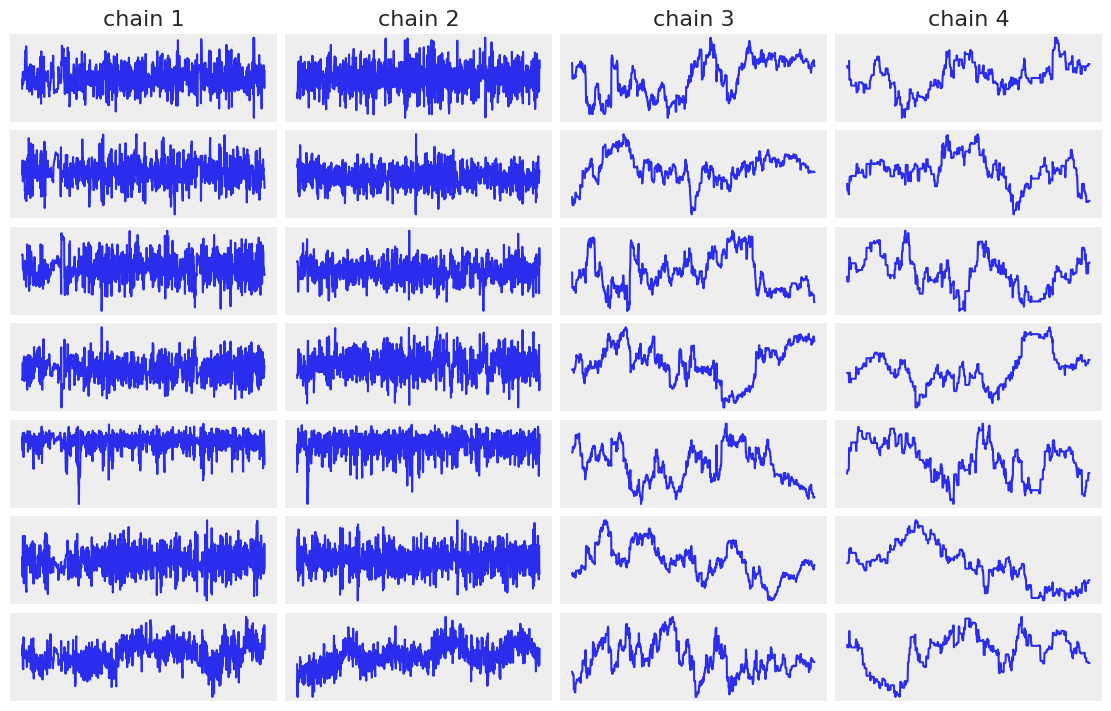

In [ ]:
fig, axs = plt.subplots(ncols = beta_post.shape[0], nrows = beta_post.shape[2], figsize=(11,7))

for chain in range(beta_post.shape[0]):
    for col in range(beta_post.shape[2]):
        axs[col, chain].plot(beta_post[chain,:,col])
        axs[col, chain].set_yticks([])
        axs[col, chain].set_xticks([])

for chain in range(beta_post.shape[0]):
    axs[0, chain].set_title(f"chain {chain+1}")
plt.show()

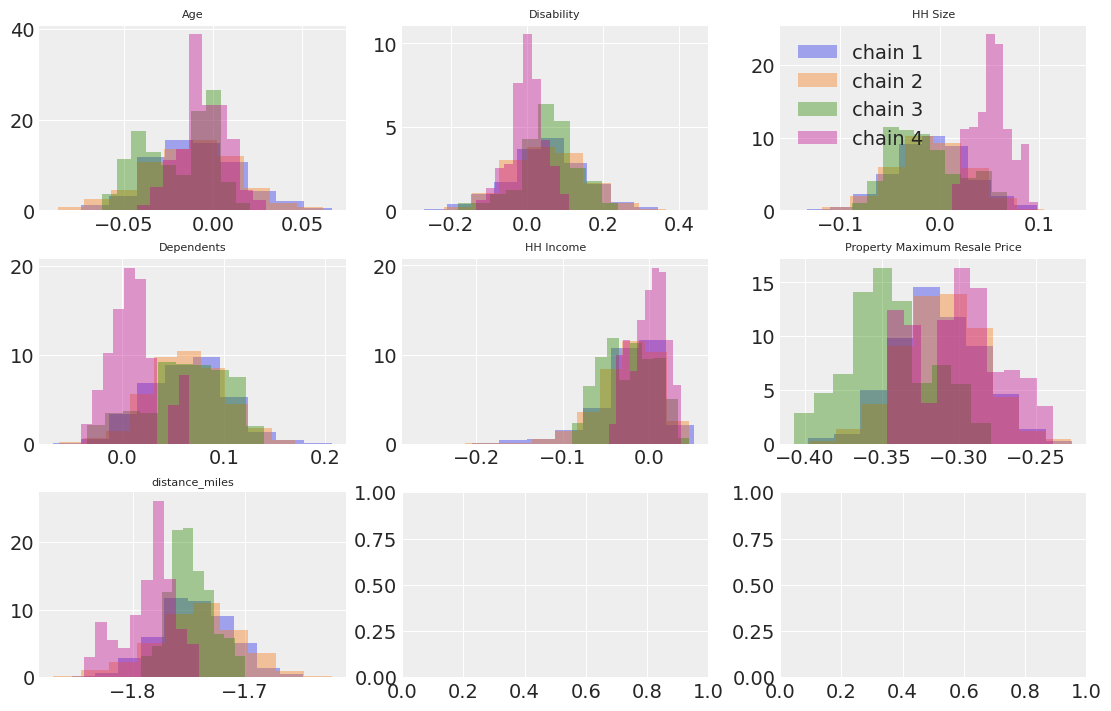

In [ ]:
fig, axs = plt.subplots(ncols = 3, nrows = 3, figsize=(11,7))
axs = axs.flatten()

for col in range(beta_post.shape[2]):
    for chain in range(beta_post.shape[0]):
        axs[col].hist(beta_post[chain,:,col], density=True, label=f"chain {chain+1}", alpha = 0.4)
    axs[col].set_title(f"{features[col]}", fontsize=8)
    
axs[2].legend()
plt.show()

Notice some stickiness in our trace and disagreement in our posterior distributions. This can be caused by a few things, but it looks like our model is having a hard time sampling. Next things to check: *priors* & *multicolinearity*. 

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

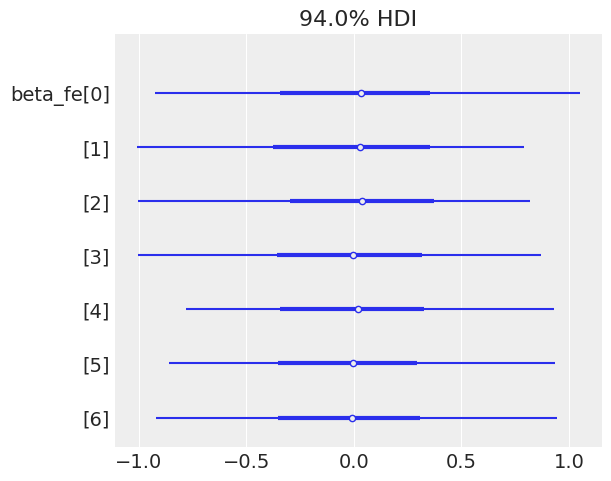

In [8]:
# looks like our priors can be wayyy more informative...
az.plot_forest(prior_predictive.prior, var_names=["beta_fe"], combined=True)

# Model 1B: More informative priors

In [ ]:
# we believe there to be multicollinearity between 'HH Size' and 'Dependents'. Which shall we choose to go into the model?
choice_dt[['HH Size', 'Dependents', 'applied']].corr()

,HH Size,Dependents,applied
HH Size,1.000000,0.776442,0.003878
Dependents,0.776442,1.000000,0.004909
applied,0.003878,0.004909,1.000000


In [ ]:
# let's also add some stronger priors!!
features = ['Age', 'Disability', 'Dependents', 'HH Income', 'Property Maximum Resale Price', 'distance_miles']
X_FE = choice_dt[features]
fe_prior_mu = np.array([0, 0.15, 0.15, 0, -0.2, -1.4])

# Defining sizes
N_app = len(app_dt)
N_FE = len(X_FE.columns)
N_obs = len(X_FE)
app_id_to_idx = {id_num: idx for idx, id_num in enumerate(app_dt['ID Number'].unique())}
app_idx_sequential = np.array([app_id_to_idx[id_num] for id_num in choice_dt['ID Number']])

# transform dataframes to arrays
X_FE_arr = X_FE.values
# scale numeric columns
X_FE_arr[:,[0,2,3,4,5]]  = (X_FE_arr[:,[0,2,3,4,5]]  - X_FE_arr[:,[0,2,3,4,5]].mean(0))  / X_FE_arr[:,[0,2,3,4,5]].std(0)
y_arr = y_applied.values

with pm.Model() as model:

    # creating data objs
    X_data = pm.Data("X_data", X_FE_arr)
    app_idx = pm.Data("app_idx", app_idx_sequential)
    y_data = pm.Data("y_data", y_arr)

    # priors
    beta_fe = pm.Normal("beta_fe", mu=fe_prior_mu, sigma=0.1)
    
    mu_app = pm.Normal("mu_app", mu=-4, sigma=1)
    sigma_app = pm.HalfNormal("sigma_app", sigma=0.3)

    # Applicant-level RE
    gamma_i = pm.Normal("gamma_i", mu=mu_app, sigma=sigma_app, shape=N_app)

    # Utility calculations
    gamma_for_obs = gamma_i[app_idx].reshape((-1,1))
    fixed_effects_term = X_data @ beta_fe.reshape((-1,1))
    eta = gamma_for_obs + fixed_effects_term
    eta = eta.flatten() 
    
    p = pm.invlogit(eta)
    p_var = pm.Deterministic("p", p)

    Y = pm.Bernoulli("Y", p=p, observed=y_data)

    # sampling
    prior_predictive = pm.sample_prior_predictive(draws=500, random_seed=42)
    idata = pm.sample(draws=1000, tune=1500, chains=4, random_seed=42)

beta_post = idata.posterior.beta_fe.values
az.summary(idata, var_names=["mu_app", "sigma_app", 'beta_fe'])

Sampling: [Y, beta_fe, gamma_i, mu_app, sigma_app]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_fe, mu_app, sigma_app, gamma_i]


/Users/pavlomysak/opt/anaconda3/envs/chapa_env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 1056 seconds.
There were 625 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_app,-5.357,0.036,-5.429,-5.289,0.008,0.010,22.0,15.0,1.41
sigma_app,0.057,0.027,0.025,0.108,0.012,0.005,6.0,31.0,1.70
beta_fe[0],-0.015,0.024,-0.056,0.031,0.001,0.000,585.0,1932.0,1.01
beta_fe[1],0.109,0.068,-0.016,0.236,0.002,0.002,973.0,1502.0,1.00
beta_fe[2],0.060,0.023,0.019,0.105,0.001,0.001,572.0,700.0,1.01
beta_fe[3],-0.022,0.033,-0.084,0.033,0.002,0.002,472.0,289.0,1.01
beta_fe[4],-0.311,0.028,-0.362,-0.258,0.002,0.001,168.0,185.0,1.01
beta_fe[5],-1.728,0.036,-1.798,-1.662,0.006,0.006,41.0,41.0,1.10


Notice, our *rhat* is starting to improve a bit, but it's not great yet...

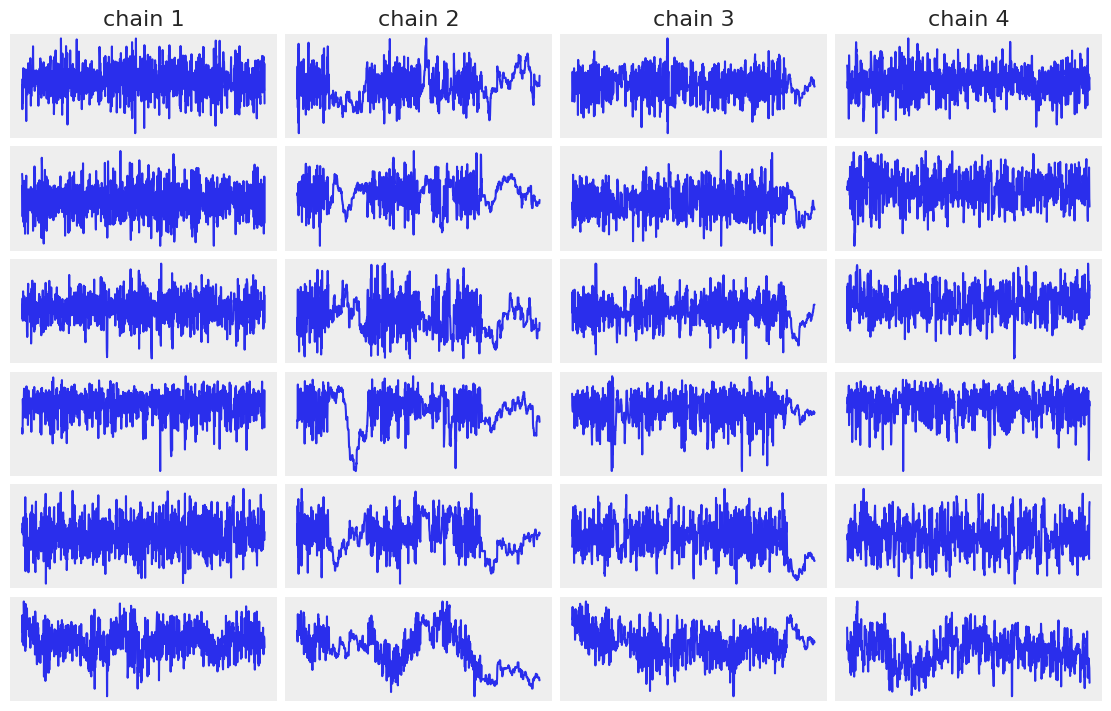

In [ ]:
fig, axs = plt.subplots(ncols = beta_post.shape[0], nrows = beta_post.shape[2], figsize=(11,7))

for chain in range(beta_post.shape[0]):
    for col in range(beta_post.shape[2]):
        axs[col, chain].plot(beta_post[chain,:,col])
        axs[col, chain].set_yticks([])
        axs[col, chain].set_xticks([])

for chain in range(beta_post.shape[0]):
    axs[0, chain].set_title(f"chain {chain+1}")
plt.show()

There's some stickiness happening in *chain 2* and *chain 3*. Will this come across in the distributions?

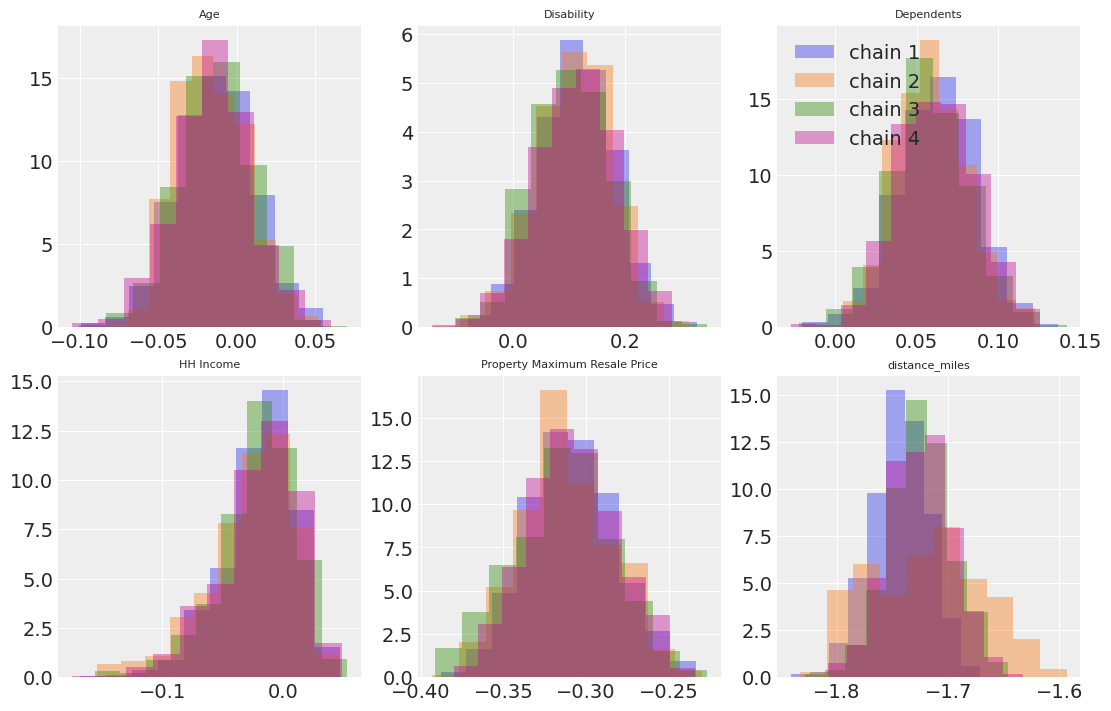

In [ ]:
fig, axs = plt.subplots(ncols = 3, nrows = 2, figsize=(11,7))
axs = axs.flatten()

for col in range(beta_post.shape[2]):
    for chain in range(beta_post.shape[0]):
        axs[col].hist(beta_post[chain,:,col], density=True, label=f"chain {chain+1}", alpha = 0.4)
    axs[col].set_title(f"{features[col]}", fontsize=8)
    
axs[2].legend()
plt.show()

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

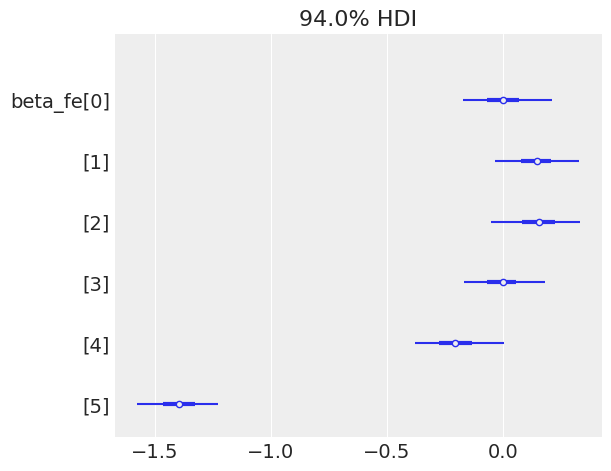

In [41]:
# these priors look way better.
az.plot_forest(prior_predictive.prior, var_names=["beta_fe"], combined=True)

Priors look better and model fit has improved (rhat)... but we can do better. Let's add race/ethnicity as a group-level effect, drop the applicant-level random effects (too computationally expensive), and retain our current informative priors. 

# Model 2 Description
---

**Hyper-Priors**
$$ \text{Fixed Effects Mean Hyper-prior: } \mu_\beta \sim \mathcal{N}([0, 0.15, 0.15, 0, -0.2, -1.4],0.1) $$
$$ \text{Fixed Effects Variance Hyper-prior: } \sigma_\beta \sim \text{Exp}(1) $$

$$ \text{Fixed Effects Priors: } \beta_\text{race} \sim \mathcal{N}(\mu_\beta, \sigma_\beta) $$
$$ \text{Applicant Slope Mean Prior: } \mu_{\text{app}} \sim \mathcal{N}(-4,1) $$
$$ \text{Applicant Slope Variance Prior: } \sigma_{\text{app}}^2 \sim \text{Half-Normal}(0.3) $$

---
**Intercept**

$$ \gamma \sim \mathcal{N}(\mu_{\text{app}}, \sigma_{\text{app}}^2) $$

---
**Utility**

$$ \eta_{ij} = \gamma + \mathbf{X_{ij}^T}\beta_\text{race} $$

$$ p_{ij} = \frac{1}{1+\text{exp}(-\eta_{ij})} $$

$$ Y_{ij} \sim \text{Bernoulli}(p_{ij}) $$

In [ ]:
features = ['Age', 'Disability', 'Dependents', 'HH Income', 'Property Maximum Resale Price', 'distance_miles']
X_FE = choice_dt[features]
fe_prior_mu = np.array([0, 0.15, 0.15, 0, -0.2, -1.4])

y_applied = choice_dt["applied"]

# Defining sizes
N_app = len(app_dt)
N_FE = len(X_FE.columns)
race_idx = choice_dt["race_norm_final"].astype("category").cat.codes.values
N_race = choice_dt["race_norm_final"].nunique()
N_obs = len(X_FE)

# transform dataframes to arrays
X_FE_arr = X_FE.values
# scale numeric columns
X_FE_arr[:,[0,2,3,4,5]]  = (X_FE_arr[:,[0,2,3,4,5]]  - X_FE_arr[:,[0,2,3,4,5]].mean(0))  / X_FE_arr[:,[0,2,3,4,5]].std(0)
y_arr = y_applied.values

with pm.Model() as model:

    # data
    X_data = pm.Data("X_data", X_FE_arr)
    race_idx_data = pm.Data("race_idx", race_idx)
    y_data = pm.Data("y_data", y_arr)

    # priors
    mu_beta = pm.Normal("mu_beta", fe_prior_mu, 0.1)
    sigma_beta = pm.Exponential("sigma_beta", 1)
    beta_fe = pm.Normal("beta_fe", mu=mu_beta, sigma=sigma_beta, shape=(N_race, N_FE))

    mu_app = pm.Normal("mu_app", mu=-4, sigma=1)
    sigma_app = pm.HalfNormal("sigma_app", sigma=0.3)

    # intercept
    gamma = pm.Normal("gamma", mu=mu_app, sigma=sigma_app)

    # Utility calculations
    race_betas = beta_fe[race_idx_data]
    fixed_effects_term = pm.math.sum(race_betas * X_data, axis=1)
    eta = gamma + fixed_effects_term
    eta = eta.flatten() 
    
    p = pm.math.sigmoid(eta)
    p_var = pm.Deterministic("p", p)

    Y = pm.Bernoulli("Y", p=p, observed=y_data)

    # sampling
    prior_predictive = pm.sample_prior_predictive(draws=500, random_seed=42)
    idata = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

beta_post = idata.posterior.beta_fe.values
az.summary(idata, var_names=["mu_app", "sigma_app", 'beta_fe', 'mu_beta', 'sigma_beta'])

Sampling: [Y, beta_fe, gamma, mu_app, mu_beta, sigma_app, sigma_beta]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta, sigma_beta, beta_fe, mu_app, sigma_app, gamma]


/Users/pavlomysak/opt/anaconda3/envs/chapa_env/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1286 seconds.
There were 460 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_app,-5.241,0.303,-5.790,-4.602,0.008,0.012,1740.0,1348.0,1.01
sigma_app,0.249,0.179,0.014,0.569,0.006,0.003,269.0,92.0,1.01
"beta_fe[0, 0]",-0.082,0.060,-0.190,0.035,0.002,0.001,1354.0,1470.0,1.00
"beta_fe[0, 1]",0.111,0.105,-0.076,0.309,0.004,0.002,860.0,2091.0,1.01
"beta_fe[0, 2]",0.079,0.055,-0.020,0.189,0.001,0.001,3251.0,1980.0,1.00
"beta_fe[0, 3]",-0.016,0.102,-0.206,0.179,0.003,0.002,1578.0,2004.0,1.00
"beta_fe[0, 4]",-0.289,0.060,-0.400,-0.166,0.003,0.003,436.0,81.0,1.01
"beta_fe[0, 5]",-1.775,0.068,-1.922,-1.666,0.002,0.001,835.0,542.0,1.00
"beta_fe[1, 0]",0.012,0.061,-0.087,0.132,0.002,0.001,717.0,779.0,1.00
"beta_fe[1, 1]",0.118,0.105,-0.078,0.306,0.004,0.002,638.0,1440.0,1.01


With a different model structure and our more informative priors, our *rhat* looks great all around!! Let's look at trace.

/var/folders/q9/vssjztfs6gd47qy2w2t2f0t80000gn/T/ipykernel_82210/1186979122.py:16: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.6, wspace=0.4)


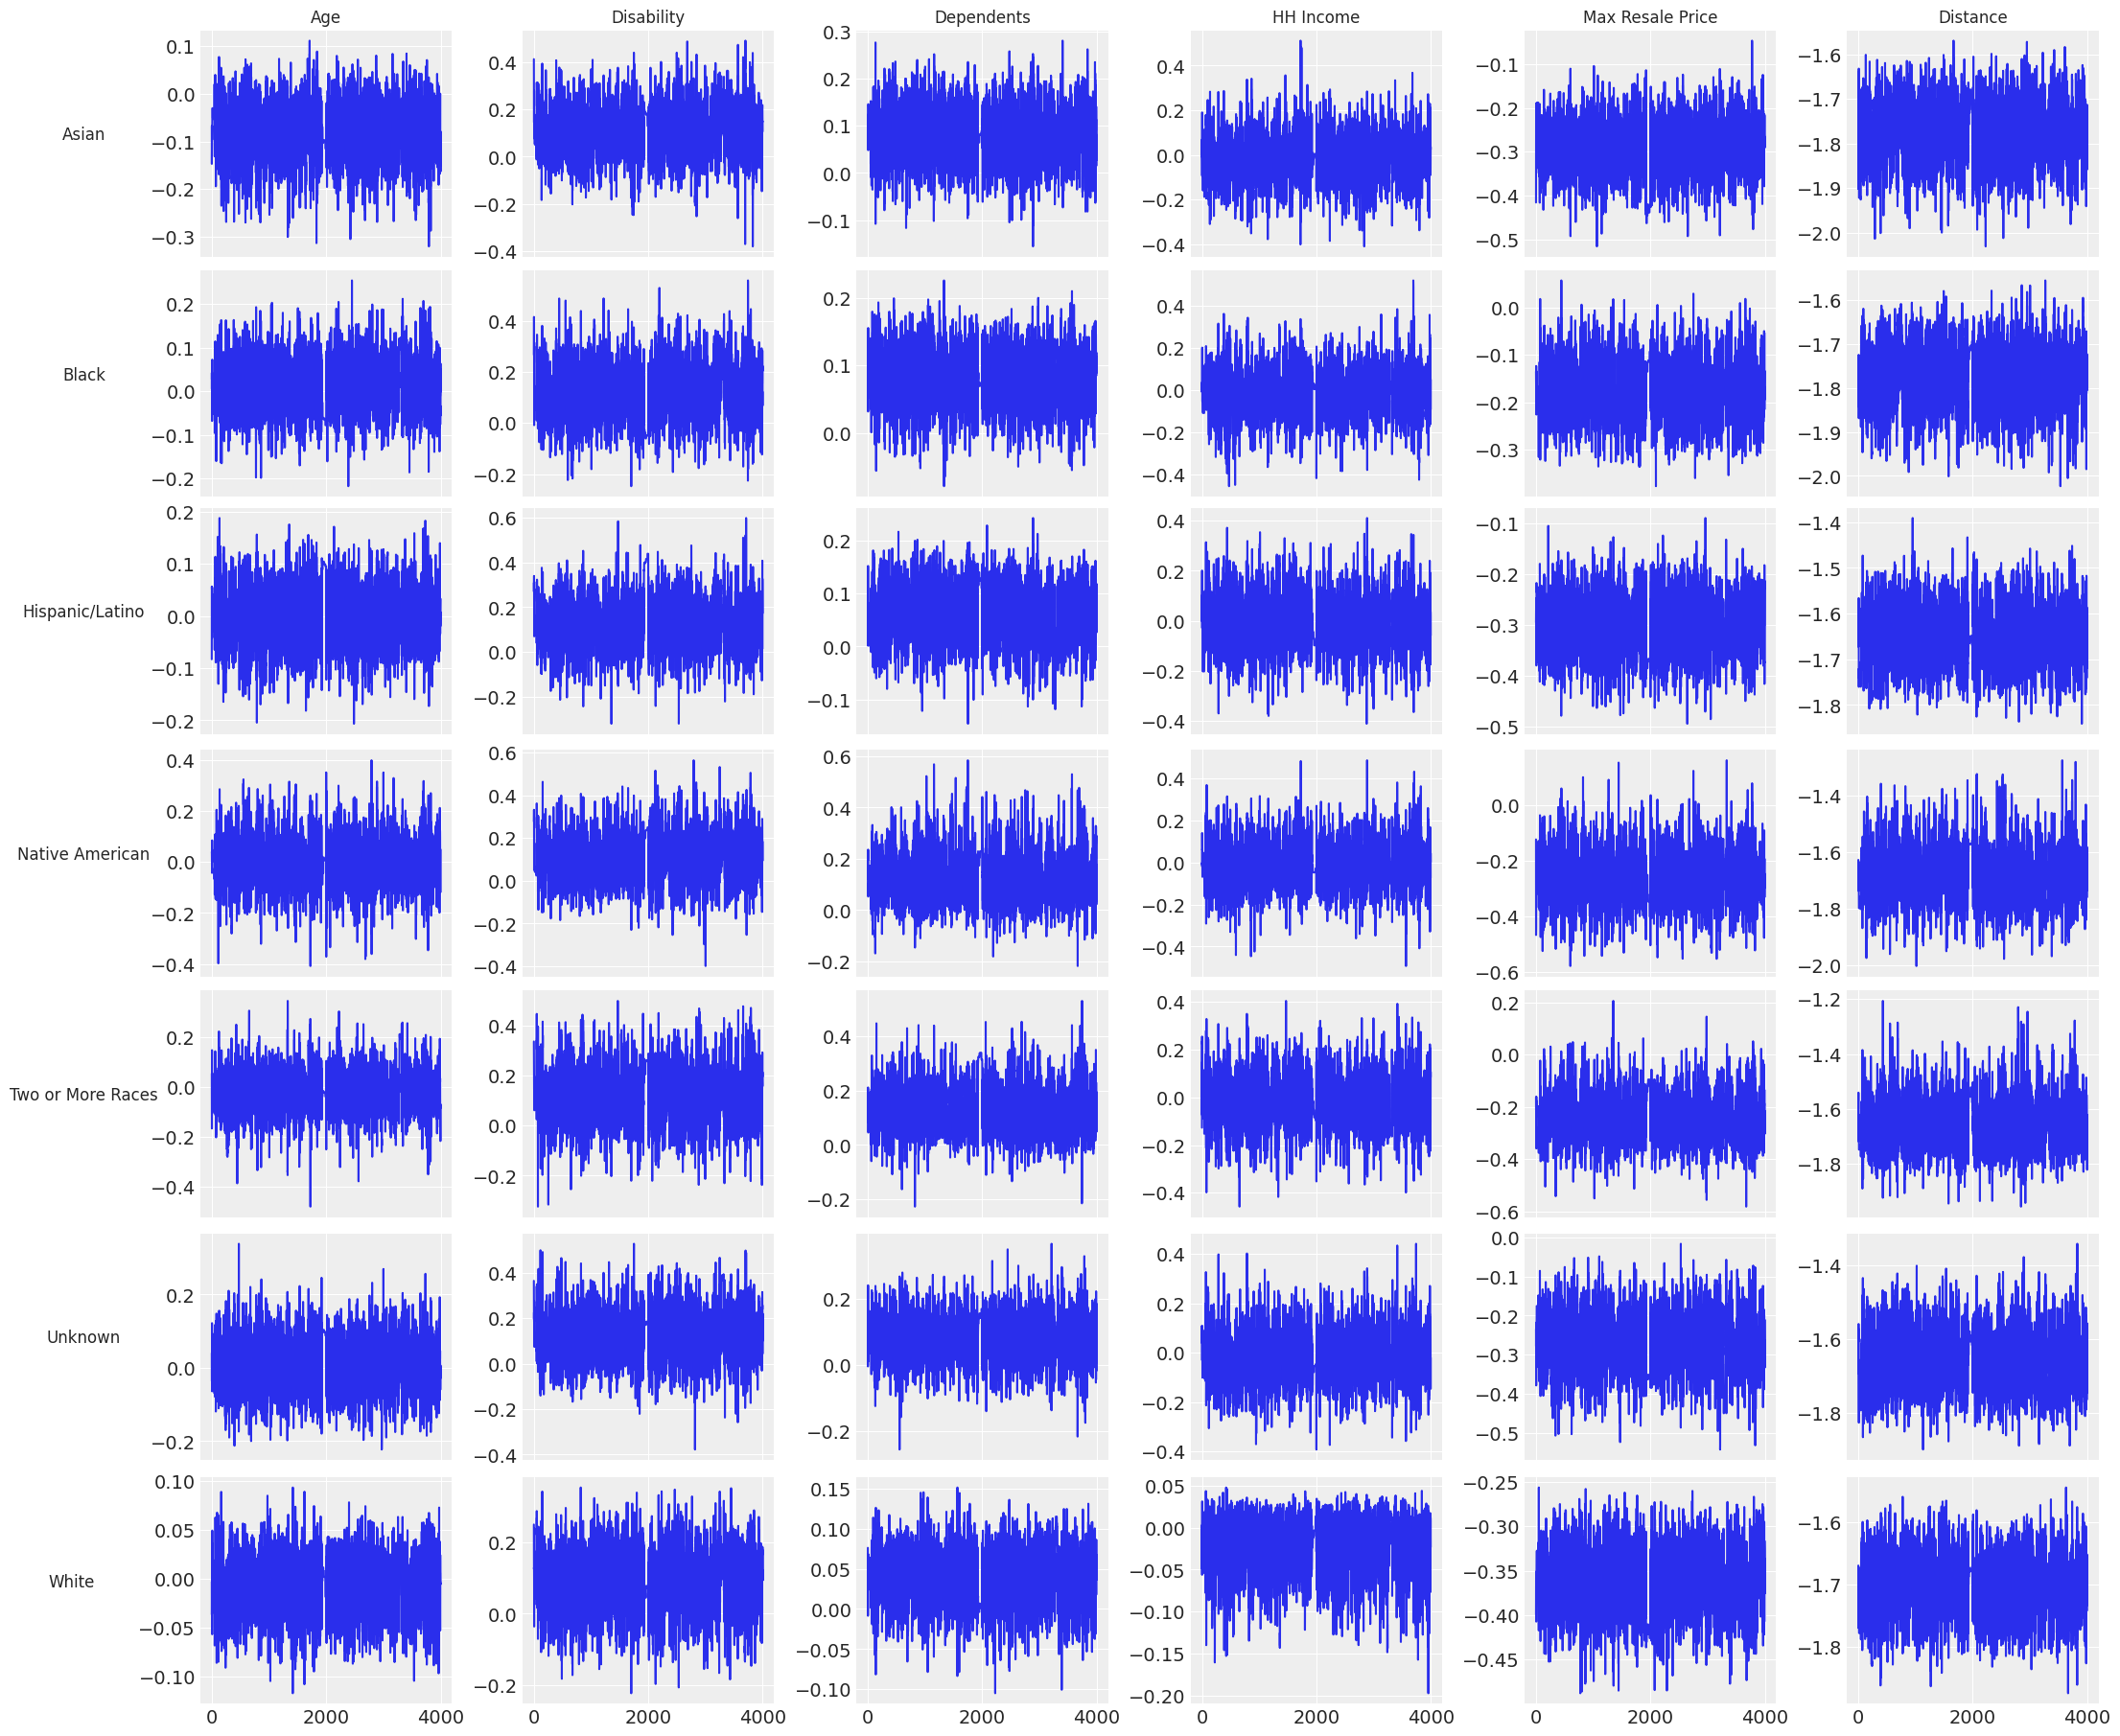

In [ ]:
# Check trace plots for beta
beta_posterior = beta_post.reshape(4000, 7, 6)

races = ['Asian', 'Black', 'Hispanic/Latino', 'Native American',
         'Two or More Races', 'Unknown', 'White']
features = ['Age', 'Disability', 'Dependents',
            'HH Income', 'Max Resale Price', 'Distance']

fig, axs = plt.subplots(
    nrows=len(races), ncols=len(features),
    figsize=(22, 18),
    sharex=True, sharey=False
)
plt.subplots_adjust(hspace=0.6, wspace=0.4)

for r in range(len(races)):
    for c in range(len(features)):
        vals = beta_posterior[:,r, c]

        axs[r, c].plot(vals)

# row/col labels
for r, race in enumerate(races):
    axs[r, 0].set_ylabel(race, fontsize=12, rotation=0, labelpad=50)
for c, feat in enumerate(features):
    axs[0, c].set_title(feat, fontsize=12)

plt.show()

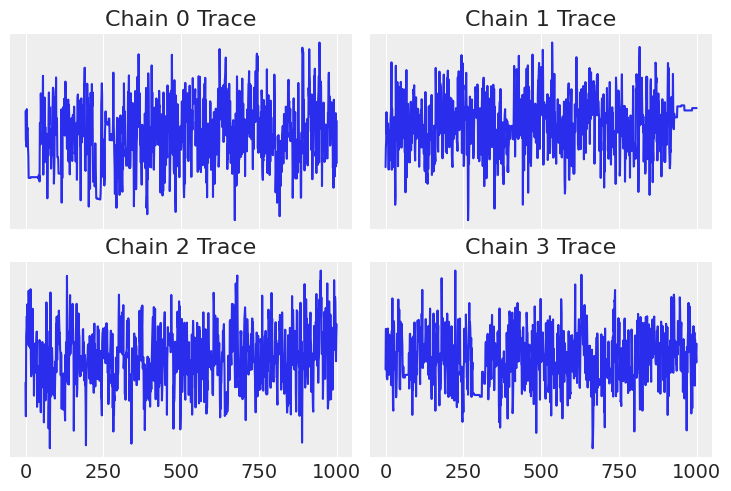

In [ ]:
# some stickiness here and there, but generally ok.

fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True)
axs = axs.flatten()

for chain in range(4):
    axs[chain].plot(idata.posterior.gamma.values[chain, :])
    axs[chain].set_title(f"Chain {chain} Trace")
    axs[chain].set_yticks([])

plt.show()

In [ ]:
fig, axs = plt.subplots(
    nrows=len(races), ncols=len(features),
    figsize=(22, 18),
    sharex=False, sharey=False, dpi=600
)

plt.subplots_adjust(hspace=0.6, wspace=0.4)

for r in range(len(races)):
    for c in range(len(features)):
        vals = beta_posterior[:, r, c]

        axs[r, c].hist(vals, density=True, bins=30)

        axs[r, c].axvline(0, color="red")

        # remove extra ticks
        axs[r, c].set_yticks([])
        
        if r != (len(races)-1):
            axs[r, c].set_xticks([])


        axs[r, c].tick_params(labelsize=8)

        if c == (len(features)-1):
            axs[r, c].set_xlim(-2.2, -1.2)
        else:
            axs[r, c].set_xlim(-0.45, 0.45)

# row/col labels
for r, race in enumerate(races):
    axs[r, 0].set_ylabel(race, fontsize=12, rotation=0, labelpad=50)
for c, feat in enumerate(features):
    axs[0, c].set_title(feat, fontsize=12)

plt.show()

/var/folders/q9/vssjztfs6gd47qy2w2t2f0t80000gn/T/ipykernel_82210/2044758254.py:7: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.6, wspace=0.4)


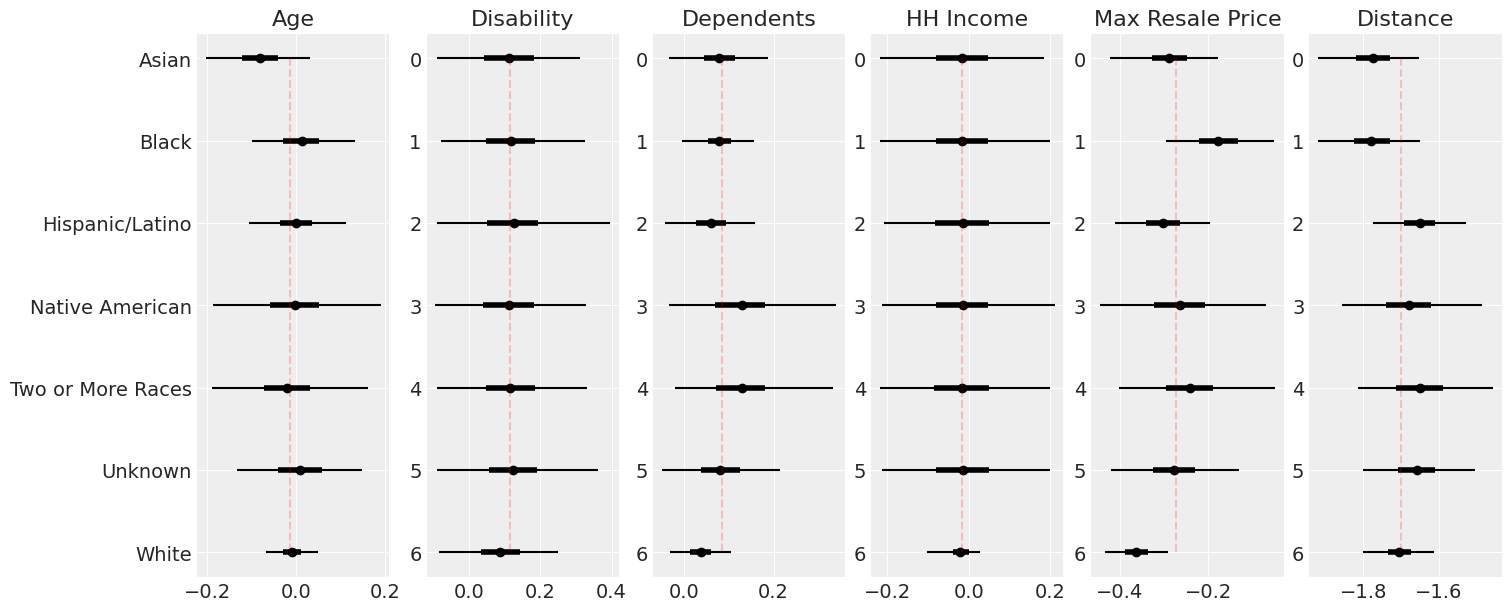

<Figure size 4320x2880 with 0 Axes>

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=beta_posterior.shape[2], figsize=(15,6))
axs = axs.flatten()

for feat in range(beta_posterior.shape[2]):

    vals = beta_posterior[:, :, feat]
    means = vals.mean(axis=0)
    ci50 = np.percentile(vals, [25, 75], axis=0)
    ci95 = np.percentile(vals, [2.5, 97.5], axis=0)
    y = np.arange(len(races))

    axs[feat].hlines(y, ci95[0], ci95[1], color='black')
    axs[feat].hlines(y, ci50[0], ci50[1], color='black', linewidth=4)
    axs[feat].plot(means, y, 'o', color='black')
    axs[feat].vlines(means.mean(), ymin=0, ymax=6, color="red", ls="--", alpha=0.2)
    axs[feat].set_title(f"{features[feat]}")

axs[0].set_yticks(y)
axs[0].set_yticklabels(races)
for feat in range(beta_posterior.shape[2]):
    axs[feat].invert_yaxis()

plt.figure(dpi=600)
plt.show()

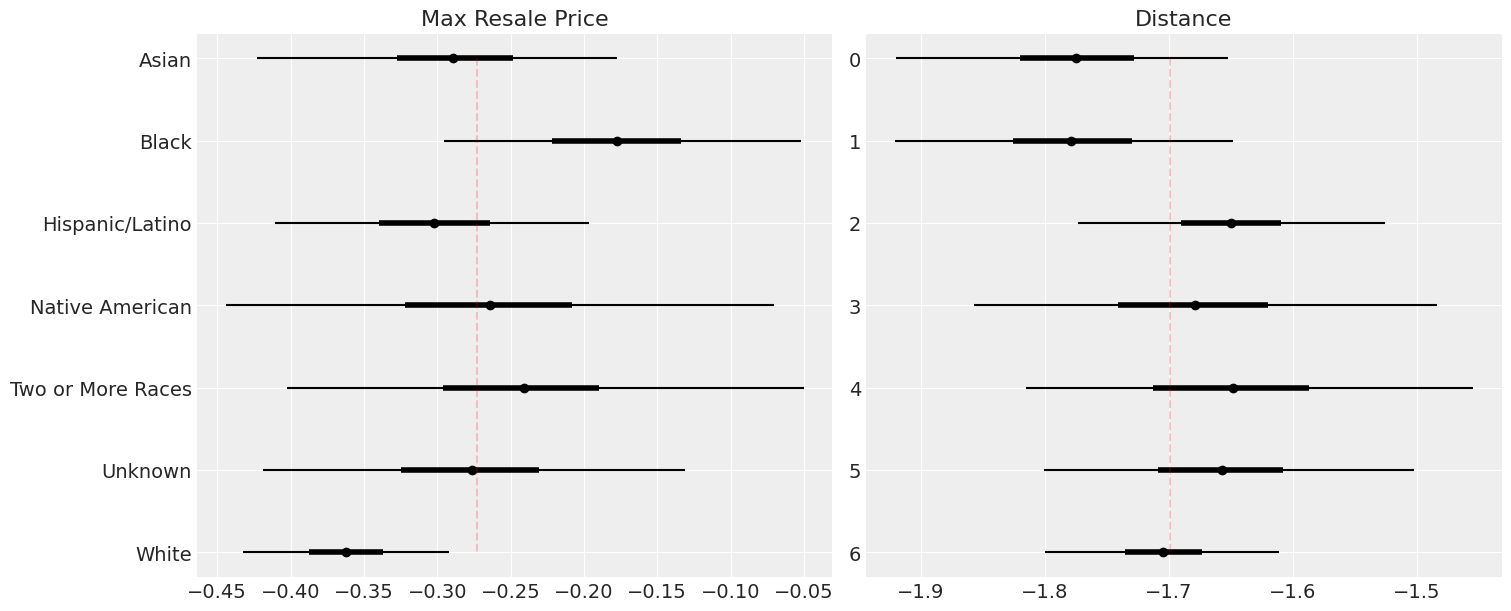

<Figure size 4320x2880 with 0 Axes>

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,6))
axs = axs.flatten()

for feat in range(2):

    vals = beta_posterior[:, :, feat+4]
    means = vals.mean(axis=0)
    ci50 = np.percentile(vals, [25, 75], axis=0)
    ci95 = np.percentile(vals, [2.5, 97.5], axis=0)
    y = np.arange(len(races))

    axs[feat].hlines(y, ci95[0], ci95[1], color='black')
    axs[feat].hlines(y, ci50[0], ci50[1], color='black', linewidth=4)
    axs[feat].plot(means, y, 'o', color='black')
    axs[feat].vlines(means.mean(), ymin=0, ymax=6, color="red", ls="--", alpha=0.2)
    axs[feat].set_title(f"{features[feat+4]}")

axs[0].set_yticks(y)
axs[0].set_yticklabels(races)
for feat in range(2):
    axs[feat].invert_yaxis()

plt.figure(dpi=600)
plt.show()

Broadly, the model finds that most applicant-level factors exert similar effects across racial and ethnic groups, with meaningful differences emerging primarily in responses to property attributes.

Across all groups, the effects associated with age, household size, and household income were near zero, indicating that these characteristics generally do not materially alter application behavior. In contrast, disability status and the number of dependents showed consistent positive associations with application probability. Applicants reporting a disability were more likely to apply, and the likelihood of applying increased incrementally with each additional dependent. Importantly, these effects did not differ meaningfully across demographic groups, suggesting that these factors operate similarly regardless of racial or ethnic background.

Group-specific variation becomes more evident when examining property-level characteristics. As the distance between an applicant’s residence and a property increased, Asian and Black applicants exhibited a sharper decline in the probability of applying than other groups. Hispanic/Latino applicants, by contrast, showed comparatively little sensitivity to distance, implying that geographic proximity plays a smaller role in their decision-making. Differences also emerged in responses to maximum resale price. Higher resale prices were associated with lower application likelihood for White applicants, while Black applicants appeared less sensitive to price. Although these effects were modest in magnitude, they were directionally consistent and suggest that price and location considerations are evaluated differently across groups.

The results indicate that while baseline applicant characteristics generally influence all groups in similar ways, heterogeneity arises in how groups respond to key property features. These findings highlight that distance and pricing structures contribute to observable differences in application behavior, even as other determinants remain stable across demographic categories.